In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    'order_id': range(1, n+1),
    'user_id': np.random.randint(1, 101, n),
    'order_date': pd.date_range('2024-01-01', periods=n, freq='H'),
    'amount': np.random.randint(10, 200, n),
    'status': np.random.choice(['completed', 'cancelled'], n, p=[0.8, 0.2])
})

df.head()

/tmp/ipykernel_43384/2551805938.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'order_date': pd.date_range('2024-01-01', periods=n, freq='H'),


,order_id,user_id,order_date,amount,status
0,1,52,2024-01-01 00:00:00,43,completed
1,2,93,2024-01-01 01:00:00,120,completed
2,3,15,2024-01-01 02:00:00,17,completed
3,4,72,2024-01-01 03:00:00,177,completed
4,5,61,2024-01-01 04:00:00,122,completed


In [ ]:
total_revenue = df['amount'].sum()

total_orders = len(df)

completed_orders = (df['status'] == 'completed').sum()

completion_rate = completed_orders / total_orders

total_revenue, total_orders, completed_orders, completion_rate

(np.int64(103107), 1000, np.int64(821), np.float64(0.821))

In [ ]:
df['date'] = df['order_date'].dt.date

daily_revenue = (
    df.groupby('date')['amount']
      .sum()
      .reset_index()
)

daily_revenue.head()

,date,amount
0,2024-01-01,2548
1,2024-01-02,2253
2,2024-01-03,2496
3,2024-01-04,2491
4,2024-01-05,2496


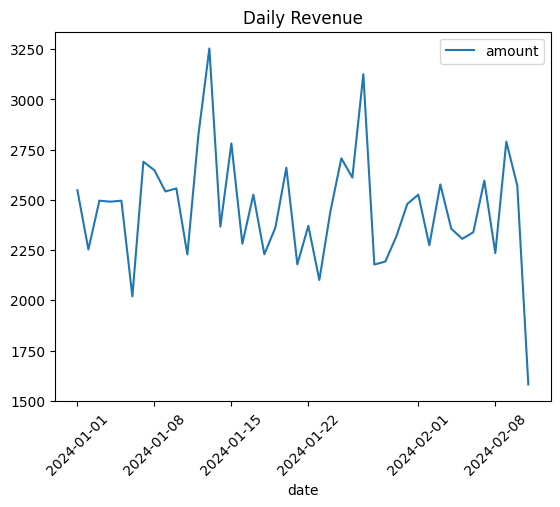

In [ ]:
import matplotlib.pyplot as plt

daily_revenue.plot(x='date', y='amount')
plt.xticks(rotation=45)
plt.title('Daily Revenue')
plt.show()

### Insights

1. Revenue fluctuates across days with visible variation.
2. Dataset shows consistent order flow with majority completed (~80%).

## D2 — Revenue by User

In this section, I analyze revenue by user to identify high-value customers and understand how revenue is distributed across the customer base.

In [ ]:
user_revenue = (
    df.groupby('user_id', as_index=False)
      .agg(
          total_revenue=('amount', 'sum'),
          total_orders=('order_id', 'count'),
          completed_orders=('status', lambda x: (x == 'completed').sum())
      )
)

user_revenue['completion_rate'] = (
    user_revenue['completed_orders'] / user_revenue['total_orders']
)

user_revenue = user_revenue.sort_values('total_revenue', ascending=False)

user_revenue.head(10)

,user_id,total_revenue,total_orders,completed_orders,completion_rate
61,62,2369,19,16,0.842105
89,90,2229,20,19,0.950000
98,99,2024,18,14,0.777778
91,92,2007,19,15,0.789474
18,19,1825,14,11,0.785714
16,17,1769,15,11,0.733333
53,54,1659,12,10,0.833333
2,3,1598,12,10,0.833333
22,23,1595,13,10,0.769231
47,48,1519,11,10,0.909091


In [ ]:
top_10_share = (
    user_revenue.head(10)['total_revenue'].sum() / user_revenue['total_revenue'].sum()
)

top_10_share

np.float64(0.18033693153714103)

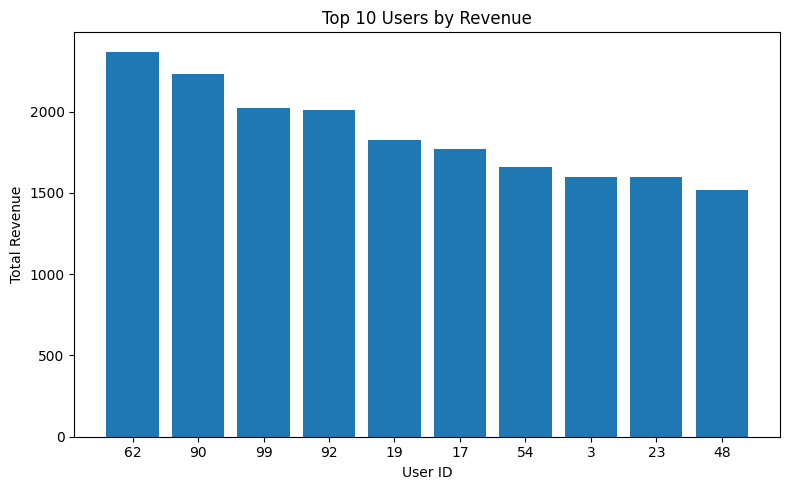

In [ ]:
import matplotlib.pyplot as plt

top_users = user_revenue.head(10)

plt.figure(figsize=(8, 5))
plt.bar(top_users['user_id'].astype(str), top_users['total_revenue'])
plt.title('Top 10 Users by Revenue')
plt.xlabel('User ID')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

### D2 Insight

Revenue is unevenly distributed across users. The top 10 users generate a disproportionately high share of total revenue.

This indicates that a relatively small group of customers contributes significantly to overall sales, highlighting the importance of customer retention, loyalty programs, and targeted engagement strategies.

This pattern is consistent with common ecommerce dynamics, where high-value customers drive a large portion of revenue (Pareto-like distribution).

## D3 — Order Behavior Segmentation

This section analyzes user behavior based on order frequency and engagement levels.

```sql
WITH user_revenue AS (
    SELECT user_id,
           SUM(amount) AS total_revenue,
           COUNT(*) AS total_orders,
           SUM(CASE WHEN status = 'completed' THEN 1 ELSE 0 END) AS completed_orders
    FROM orders
    GROUP BY user_id
),

segmented AS (
    SELECT *,
           NTILE(3) OVER (ORDER BY total_revenue) AS segment
    FROM user_revenue
)

SELECT segment,
       COUNT(*) AS users,
       AVG(total_revenue) AS avg_revenue,
       AVG(completed_orders * 1.0 / NULLIF(total_orders,0)) AS avg_completion_rate
FROM segmented
GROUP BY segment;
```

segment_summary

In [ ]:
user_revenue['user_segment'] = pd.qcut(
    user_revenue['total_revenue'],
    q=3,
    labels=['low', 'medium', 'high']
)

user_revenue.head()

,user_id,total_revenue,total_orders,completed_orders,completion_rate,user_segment
61,62,2369,19,16,0.842105,high
89,90,2229,20,19,0.950000,high
98,99,2024,18,14,0.777778,high
91,92,2007,19,15,0.789474,high
18,19,1825,14,11,0.785714,high


In [ ]:
segment_summary = (
    user_revenue.groupby('user_segment')
    .agg(
        users=('user_id', 'count'),
        avg_revenue=('total_revenue', 'mean'),
        avg_completion_rate=('completion_rate', 'mean')
    )
)

segment_summary

/tmp/ipykernel_43384/618330044.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_revenue.groupby('user_segment')


,users,avg_revenue,avg_completion_rate
user_segment,,,
low,35,606.085714,0.802336
medium,31,1021.516129,0.797144
high,34,1477.264706,0.854687


### D3 Insight

Users were segmented into low, medium, and high revenue groups using quantile-based binning.

High-value users generate significantly higher revenue and exhibit the highest completion rates (~85%), indicating more consistent purchasing behavior.

Interestingly, medium-value users show slightly lower completion rates compared to both low and high segments, suggesting potential friction or drop-off in this group.

This segmentation highlights an opportunity to improve conversion for medium-value users while prioritizing retention of high-value customers.

From a business perspective:
- High-value users → prioritize retention (loyalty programs, VIP offers)
- Medium-value users → optimize conversion (checkout UX, discounts)
- Low-value users → growth potential (engagement campaigns)

## D4 — User Spending Growth Over Time

This section analyzes how user spending evolves over time by comparing each order to the user's previous order.

The goal is to identify users who demonstrate increasing spending behavior, which may indicate higher engagement, successful upselling, or growing customer value.

To measure this, each transaction is compared to the previous one using time-based ordering. The relative change in order value is calculated, allowing us to detect significant growth patterns.

Users with repeated increases in spending (e.g., ≥20% growth between orders) are identified as high-potential customers.

This analysis helps uncover:
- users with increasing purchasing power
- opportunities for upselling and targeted marketing
- behavioral patterns similar to high-value customers

From a business perspective:
- growing users → strong candidates for premium offers
- stable users → retention focus
- declining users → potential churn risk

In [ ]:
import seaborn as sns

orders = sns.load_dataset('tips')
orders.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
orders = orders.rename(columns={
    'size': 'user_id',
    'total_bill': 'amount'
})

orders['created_at'] = pd.to_datetime(orders.index, unit='D')

orders = orders[['user_id', 'created_at', 'amount']].reset_index(drop=True)
orders.head()

,user_id,created_at,amount
0,2,1970-01-01,16.99
1,3,1970-01-02,10.34
2,3,1970-01-03,21.01
3,2,1970-01-04,23.68
4,4,1970-01-05,24.59


In [ ]:
orders = orders.sort_values(['user_id', 'created_at']).reset_index(drop=True)
orders.head()

,user_id,created_at,amount,prev_amount,growth_pct
0,1,1970-03-09,3.07,NaN,NaN
1,1,1970-03-24,10.07,3.07,2.280130
2,1,1970-04-22,7.25,10.07,-0.280040
3,1,1970-08-11,8.58,7.25,0.183448
4,2,1970-01-01,16.99,NaN,NaN


In [ ]:
orders.info()
orders.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 67 to 156
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     244 non-null    int64         
 1   created_at  244 non-null    datetime64[ns]
 2   amount      244 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 7.6 KB


,0
user_id,0
created_at,0
amount,0


In [ ]:
orders['prev_amount'] = (
    orders
    .groupby('user_id')['amount']
    .shift(1)
)

orders.head()

,user_id,created_at,amount,prev_amount
67,1,1970-03-09,3.07,NaN
82,1,1970-03-24,10.07,3.07
111,1,1970-04-22,7.25,10.07
222,1,1970-08-11,8.58,7.25
0,2,1970-01-01,16.99,NaN


In [ ]:
import numpy as np

orders['growth_pct'] = np.where(
    orders['prev_amount'].isna() | (orders['prev_amount'] == 0),
    np.nan,
    (orders['amount'] - orders['prev_amount']) / orders['prev_amount']
)

orders.head()

,user_id,created_at,amount,prev_amount,growth_pct
67,1,1970-03-09,3.07,NaN,NaN
82,1,1970-03-24,10.07,3.07,2.280130
111,1,1970-04-22,7.25,10.07,-0.280040
222,1,1970-08-11,8.58,7.25,0.183448
0,2,1970-01-01,16.99,NaN,NaN


In [ ]:
growth_events = orders.loc[
    orders['growth_pct'] >= 0.20
].copy()

growth_events.head()

,user_id,created_at,amount,prev_amount,growth_pct
82,1,1970-03-24,10.07,3.07,2.280130
3,2,1970-01-04,23.68,16.99,0.393761
8,2,1970-01-09,15.04,8.77,0.714937
12,2,1970-01-13,15.42,10.27,0.501461
15,2,1970-01-16,21.58,14.83,0.455158


In [ ]:
user_growth_summary = (
    growth_events
    .groupby('user_id', as_index=False)
    .agg(
        growth_event_count=('growth_pct', 'size'),
        avg_growth_pct=('growth_pct', 'mean'),
        max_growth_pct=('growth_pct', 'max'),
        latest_growth_event=('created_at', 'max')
    )
    .sort_values(
        ['growth_event_count', 'max_growth_pct'],
        ascending=[False, False]
    )
)

# Format for readability
user_growth_summary['avg_growth_pct'] = (
    user_growth_summary['avg_growth_pct'] * 100
).round(2)

user_growth_summary['max_growth_pct'] = (
    user_growth_summary['max_growth_pct'] * 100
).round(2)

user_growth_summary.head()

,user_id,growth_event_count,avg_growth_pct,max_growth_pct,latest_growth_event
1,2,56,63.52,339.31,1970-08-26
3,4,13,54.63,113.89,1970-08-01
2,3,11,78.45,159.52,1970-08-27
0,1,1,228.01,228.01,1970-03-24
5,6,1,78.08,78.08,1970-06-06


In [ ]:
user_growth_summary.head(10)

,user_id,growth_event_count,avg_growth_pct,max_growth_pct,latest_growth_event
1,2,56,63.52,339.31,1970-08-26
3,4,13,54.63,113.89,1970-08-01
2,3,11,78.45,159.52,1970-08-27
0,1,1,228.01,228.01,1970-03-24
5,6,1,78.08,78.08,1970-06-06
4,5,1,47.22,47.22,1970-07-07


**Insight**

Using a LAG / shift pattern, I compared each order amount to the user's previous order and flagged cases where spending increased by at least **20%**.

This approach detects **change in behavior**, not just large absolute values. A moderate order can still be meaningful if it is much higher than the user's usual recent spending.

At the user level, this makes it possible to identify:

*   customers showing upward spending momentum
*   users suitable for upselling or premium targeting
*   behavioral signals that resemble higher-value customers

This pattern is highly reusable in analytics because the same logic can be used for:
*  transaction growth
*  fraud spikes
*  activity surges
*  customer value expansion

Although the source data was synthetic, the workflow mirrors a real analytics task:
**sort events → get previous event → calculate change → flag important movements → aggregate by user**.